In [1]:
import numpy as np
import pickle
from qiskit_nature.second_q.operators import SpinOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
n_qubit = 1
dim     = 2**n_qubit
mapper = LogarithmicMapper()
t = 0.5
nld = 11
lds = np.linspace(0,1,num=nld)
Hld = []
i = 0
for ld in lds:
    h = SpinOp({
        "X_0": t,  
        "Z_0": -1.0 + 2.0* ld
    },
    spin=1/2
    )
    Hld.append(2*mapper.map(h.simplify())) # 2 is due to spin 1/2
    print(Hld[i])
    i +=1
h = SpinOp({
    "Z_0": 2.0
},
spin=1/2
)
Hp = 2*mapper.map(h.simplify()) # 2 is due to spin 1/2

# exact eigenvalues
ell  = np.zeros((nld,dim),dtype=float)
vll  = np.zeros((nld,dim,dim),dtype=complex)
for ild in range(nld):
    El, Vl = np.linalg.eigh(Hld[ild].to_matrix())
    indx = np.argsort(El.real)
    for i in range(dim):
        ell[ild,i]   = El[indx[i]].real
        vll[ild,:,i] = Vl[:,indx[i]]

X = np.zeros((2,2),dtype=complex)
Y = np.zeros((2,2),dtype=complex)
Z = np.zeros((2,2),dtype=complex)

X[0,1] = 1; X[1,0] = 1
Y[0,1] = -1j; Y[1,0] = 1j
Z[0,0] = 1; Z[1,1] = -1

# exact results
norm_exact   = np.ones((nld,dim),dtype=float)
E_exact      = np.zeros((nld,dim),dtype=float)
E_exact[0,:] = ell[0,:]
for k in range(dim):
    phi = vll[0,:,k]
    for ild in range(1,nld):
        Proj_matrix = np.outer(vll[ild,:,k],vll[ild,:,k].conj())
        phi = Proj_matrix@phi
        norm_exact[ild,k] = phi.conj()@phi
        E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
X_exact = np.zeros((nld,dim),dtype=float)
Y_exact = np.zeros((nld,dim),dtype=float)
Z_exact = np.zeros((nld,dim),dtype=float)
for ild in range(nld):
    for k in range(dim):
        X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
        Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
        Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]

/home/mchan/qiskit/venv/lib/python3.8/site-packages/qiskit_nature/second_q/mappers/qubit_mapper.py:188: PauliSumOpDeprecationWarning: PauliSumOp is deprecated as of version 0.6.0 and support for them will be removed no sooner than 3 months after the release. Instead, use SparsePauliOp. You can switch to SparsePauliOp immediately, by setting `qiskit_nature.settings.use_pauli_sum_op` to `False`.
  qubit_ops[name] = self._map_single(second_q_op, register_length=register_length)


0.5 * X
- 1.0 * Z
0.5 * X
- 0.8 * Z
0.5 * X
- 0.6 * Z
0.5 * X
- 0.3999999999999999 * Z
0.5 * X
- 0.19999999999999996 * Z
0.5 * X
0.5 * X
+ 0.20000000000000018 * Z
0.5 * X
+ 0.40000000000000013 * Z
0.5 * X
+ 0.6000000000000001 * Z
0.5 * X
+ 0.8 * Z
0.5 * X
+ 1.0 * Z


/tmp/ipykernel_2379/986796965.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  norm_exact[ild,k] = phi.conj()@phi
/tmp/ipykernel_2379/986796965.py:58: ComplexWarning: Casting complex values to real discards the imaginary part
  E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
/tmp/ipykernel_2379/986796965.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
/tmp/ipykernel_2379/986796965.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
/tmp/ipykernel_2379/986796965.py:66: ComplexWarning: Casting complex values to real discards the imaginary part
  Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]


In [2]:
E_sim          = np.zeros((nld,dim),dtype=float)
std_E_sim      = np.zeros((nld,dim),dtype=float)
norm_sim       = np.zeros((nld,dim),dtype=float)
std_norm_sim   = np.zeros((nld,dim),dtype=float)
with open('../exact_simulator/norm.E.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norm_sim[ild,k]     = float(ls[k*4+1])
            std_norm_sim[ild,k] = float(ls[k*4+2])
            E_sim[ild,k]        = float(ls[k*4+3])
            std_E_sim[ild,k]    = float(ls[k*4+4])
            #print(norm_ibmq[ild,k],std_norm_ibmq[ild,k],E_ibmq[ild,k],std_E_ibmq[ild,k])
        ild += 1

X_sim          = np.zeros((nld),dtype=float)
std_X_sim      = np.zeros((nld),dtype=float)
Y_sim          = np.zeros((nld),dtype=float)
std_Y_sim      = np.zeros((nld),dtype=float)
Z_sim          = np.zeros((nld),dtype=float)
std_Z_sim      = np.zeros((nld),dtype=float)
F_sim          = np.zeros((nld),dtype=float)
std_F_sim      = np.zeros((nld),dtype=float)

with open('../exact_simulator/xyz.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        X_sim[ild]      = float(ls[1])
        std_X_sim[ild]  = float(ls[2])
        Y_sim[ild]      = float(ls[3])
        std_Y_sim[ild]  = float(ls[4])
        Z_sim[ild]      = float(ls[5])
        std_Z_sim[ild]  = float(ls[6])
        F_sim[ild]      = float(ls[7])
        std_F_sim[ild]  = float(ls[8])
        #print(X_ibmq[ild],std_X_ibmq[ild],Y_ibmq[ild],std_Y_ibmq[ild],Z_ibmq[ild],std_Z_ibmq[ild])
        ild += 1

In [3]:
E_ibmq          = np.zeros((nld,dim),dtype=float)
std_E_ibmq      = np.zeros((nld,dim),dtype=float)
norm_ibmq       = np.zeros((nld,dim),dtype=float)
std_norm_ibmq   = np.zeros((nld,dim),dtype=float)
with open('./O0R0/norm.E.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norm_ibmq[ild,k]     = float(ls[k*4+1])
            std_norm_ibmq[ild,k] = float(ls[k*4+2])
            E_ibmq[ild,k]      = float(ls[k*4+3])
            std_E_ibmq[ild,k]  = float(ls[k*4+4])
            #print(norm_ibmq[ild,k],std_norm_ibmq[ild,k],E_ibmq[ild,k],std_E_ibmq[ild,k])
        ild += 1

X_ibmq          = np.zeros((nld),dtype=float)
std_X_ibmq      = np.zeros((nld),dtype=float)
Y_ibmq          = np.zeros((nld),dtype=float)
std_Y_ibmq      = np.zeros((nld),dtype=float)
Z_ibmq          = np.zeros((nld),dtype=float)
std_Z_ibmq      = np.zeros((nld),dtype=float)
F_ibmq          = np.zeros((nld),dtype=float)
std_F_ibmq      = np.zeros((nld),dtype=float)

with open('./O0R0/xyz.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        X_ibmq[ild]      = float(ls[1])
        std_X_ibmq[ild]  = float(ls[2])
        Y_ibmq[ild]      = float(ls[3])
        std_Y_ibmq[ild]  = float(ls[4])
        Z_ibmq[ild]      = float(ls[5])
        std_Z_ibmq[ild]  = float(ls[6])
        F_ibmq[ild]      = float(ls[7])
        std_F_ibmq[ild]  = float(ls[8])
        #print(X_ibmq[ild],std_X_ibmq[ild],Y_ibmq[ild],std_Y_ibmq[ild],Z_ibmq[ild],std_Z_ibmq[ild])
        ild += 1

In [4]:
E_ibmq_em        = np.zeros((nld,dim),dtype=float)
std_E_ibmq_em    = np.zeros((nld,dim),dtype=float)
norm_ibmq_em     = np.zeros((nld,dim),dtype=float)
std_norm_ibmq_em = np.zeros((nld,dim),dtype=float)
with open('./O3R1/norm.E.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        for k in range(dim):
            norm_ibmq_em[ild,k]     = float(ls[k*4+1])
            std_norm_ibmq_em[ild,k] = float(ls[k*4+2])
            E_ibmq_em[ild,k]        = float(ls[k*4+3])
            std_E_ibmq_em[ild,k]    = float(ls[k*4+4])
        ild += 1

X_ibmq_em          = np.zeros((nld),dtype=float)
std_X_ibmq_em      = np.zeros((nld),dtype=float)
Y_ibmq_em          = np.zeros((nld),dtype=float)
std_Y_ibmq_em      = np.zeros((nld),dtype=float)
Z_ibmq_em          = np.zeros((nld),dtype=float)
std_Z_ibmq_em      = np.zeros((nld),dtype=float)
F_ibmq_em          = np.zeros((nld),dtype=float)
std_F_ibmq_em      = np.zeros((nld),dtype=float)

with open('./O3R1/xyz.save','r') as file_:
    ild = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        X_ibmq_em[ild]      = float(ls[1])
        std_X_ibmq_em[ild]  = float(ls[2])
        Y_ibmq_em[ild]      = float(ls[3])
        std_Y_ibmq_em[ild]  = float(ls[4])
        Z_ibmq_em[ild]      = float(ls[5])
        std_Z_ibmq_em[ild]  = float(ls[6])
        F_ibmq_em[ild]      = float(ls[7])
        std_F_ibmq_em[ild]  = float(ls[8])
        ild += 1

<Figure size 3047.24x3047.24 with 0 Axes>

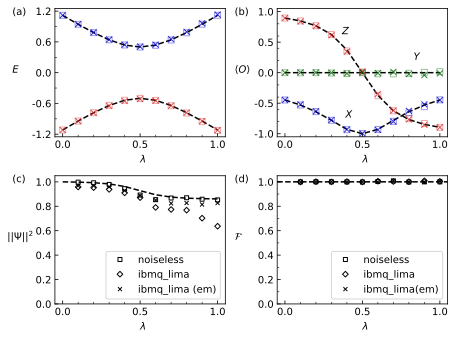

In [7]:
# draw figure
#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('pdf', 'svg')
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cm    = 1.0/2.54
rat   = 1.5
width = 8.6*cm * 1.5
height = 8.6*cm  * 1.5
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',color='black')

marker_style_1_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.4,  fillstyle='none')
marker_style_1_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.4,  fillstyle='none')
marker_style_1_3  = dict(marker='s', linestyle='none', color='darkgreen', alpha=0.4,  fillstyle='none')

marker_style_2_1  = dict(marker='D', linestyle='none', color='tab:red', alpha=0.6,  fillstyle='none')
marker_style_2_2  = dict(marker='D', linestyle='none', color='mediumblue', alpha=0.6,  fillstyle='none')
marker_style_2_3  = dict(marker='D', linestyle='none', color='darkgreen', alpha=0.6,  fillstyle='none')

marker_style_3_1  = dict(marker='x', linestyle='none', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_3_2  = dict(marker='x', linestyle='none', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_3  = dict(marker='x', linestyle='none', color='darkgreen', alpha=0.8,  fillstyle='none')

marker_style_4  = dict(marker='s', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_5  = dict(marker='D', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_6  = dict(marker='x', linestyle='none', color='black', alpha=1.0,  fillstyle='none')


fig, axes = plt.subplots(2,2)

# plot (a)

y_min    = -1.25
y_max    =  1.25

x_min    =  -0.05
x_max    =  1.05

axes[0,0].set_xlim(x_min,x_max)
axes[0,0].set_ylim(y_min,y_max)
# setup labels
axes[0,0].text(-0.25,0.95,'(a)',transform=axes[0,0].transAxes)
axes[0,0].text(0.5,-0.2,r'$\lambda$',transform=axes[0,0].transAxes)
axes[0,0].text(-0.25,0.5,r'$E$',transform=axes[0,0].transAxes)
# setup tics
axes[0,0].tick_params(axis='x', which='both', direction='in')
axes[0,0].tick_params(axis='y', which='both', direction='in')
axes[0,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,0].xaxis.set_major_formatter('{x:0.1f}')
axes[0,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,0].yaxis.set_major_locator(ticker.MultipleLocator(0.6))
axes[0,0].yaxis.set_major_formatter('{x:0.1f}')
axes[0,0].yaxis.set_minor_locator(ticker.MultipleLocator(0.3))

# plot
axes[0,0].plot(lds,E_exact[:,0], label='', **marker_style_ref)
axes[0,0].plot(lds,E_exact[:,1], label='', **marker_style_ref)

axes[0,0].plot(lds,E_sim[:,0], label ='', markersize=6, **marker_style_1_1)
axes[0,0].plot(lds,E_sim[:,1], label ='', markersize=6, **marker_style_1_2)

#axes[0,0].plot(lds,E_ibmq[:,0], label='', markersize=4, **marker_style_2_1)
#axes[0,0].plot(lds,E_ibmq[:,1], label='', markersize=4, **marker_style_2_2)

axes[0,0].plot(lds,E_ibmq_em[:,0], label='', markersize=6, **marker_style_3_1)
axes[0,0].plot(lds,E_ibmq_em[:,1], label='', markersize=6, **marker_style_3_2)


# plot (b)
y_min    = -1.05
y_max    =  1.05

x_min    =  -0.05
x_max    =  1.05

axes[0,1].set_xlim(x_min,x_max)
axes[0,1].set_ylim(y_min,y_max)
# setup labels
axes[0,1].text(-0.25,0.95,'(b)',transform=axes[0,1].transAxes)
axes[0,1].text(0.5,-0.2,s=r'$\lambda$',transform=axes[0,1].transAxes)
axes[0,1].text(-0.25,0.5,s=r'$\langle O\rangle$',transform=axes[0,1].transAxes)


axes[0,1].text(0.4,0.15,s=r'$X$',transform=axes[0,1].transAxes)
axes[0,1].text(0.8,0.6,s=r'$Y$',transform=axes[0,1].transAxes)
axes[0,1].text(0.38,0.8,s=r'$Z$',transform=axes[0,1].transAxes)
# setup tics
axes[0,1].tick_params(axis='x', which='both', direction='in')
axes[0,1].tick_params(axis='y', which='both', direction='in')
axes[0,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].xaxis.set_major_formatter('{x:0.1f}')
axes[0,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,1].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].yaxis.set_major_formatter('{x:0.1f}')
axes[0,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.2))

# plot
axes[0,1].plot(lds,Z_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,X_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,Y_exact[:,0], label='', **marker_style_ref)

axes[0,1].plot(lds,Z_sim[:], label ='', markersize=6, **marker_style_1_1)
axes[0,1].plot(lds,X_sim[:], label ='', markersize=6, **marker_style_1_2)
axes[0,1].plot(lds,Y_sim[:], label ='', markersize=6, **marker_style_1_3)

#axes[0,1].plot(lds,Z_ibmq[:], label ='', markersize=4, **marker_style_2_1)
#axes[0,1].plot(lds,X_ibmq[:], label ='', markersize=4, **marker_style_2_2)
#axes[0,1].plot(lds,Y_ibmq[:], label ='', markersize=4, **marker_style_2_3)

axes[0,1].plot(lds,Z_ibmq_em[:], label ='', markersize=6, **marker_style_3_1)
axes[0,1].plot(lds,X_ibmq_em[:], label ='', markersize=6, **marker_style_3_2)
axes[0,1].plot(lds,Y_ibmq_em[:], label ='', markersize=6, **marker_style_3_3)

# plot (c)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,0].set_xlim(x_min,x_max)
axes[1,0].set_ylim(y_min,y_max)
# setup labels
axes[1,0].text(-0.25,0.95,'(c)',transform=axes[1,0].transAxes)
axes[1,0].text(0.5,-0.2,r'$\lambda$',transform=axes[1,0].transAxes)
axes[1,0].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[1,0].transAxes)
# setup tics
axes[1,0].tick_params(axis='x', which='both', direction='in')
axes[1,0].tick_params(axis='y', which='both', direction='in')
axes[1,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,0].xaxis.set_major_formatter('{x:0.1f}')
axes[1,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,0].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,0].plot(lds,norm_exact[:,0], label='', **marker_style_ref)

axes[1,0].plot(lds[1:],norm_sim[1:,0], label ='noiseless', markersize=4, **marker_style_4)

axes[1,0].plot(lds[1:],norm_ibmq[1:,0], label='ibmq_lima', markersize=4, **marker_style_5)

axes[1,0].plot(lds[1:],norm_ibmq_em[1:,0], label='ibmq_lima (em)', markersize=4, **marker_style_6)

axes[1,0].legend(loc='lower right')

# plot (d)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,1].set_xlim(x_min,x_max)
axes[1,1].set_ylim(y_min,y_max)
# setup labels
axes[1,1].text(-0.25,0.95,'(d)',transform=axes[1,1].transAxes)
axes[1,1].text(0.5,-0.2,r'$\lambda$',transform=axes[1,1].transAxes)
axes[1,1].text(-0.25,0.5,r'$\mathcal{F}$',transform=axes[1,1].transAxes)
# setup tics
axes[1,1].tick_params(axis='x', which='both', direction='in')
axes[1,1].tick_params(axis='y', which='both', direction='in')
axes[1,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,1].xaxis.set_major_formatter('{x:0.1f}')
axes[1,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,1].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,1].axhline(y=1.0, label='', **marker_style_ref)

axes[1,1].plot(lds[1:],F_sim[1:], label ='noiseless', markersize=4, **marker_style_4)

axes[1,1].plot(lds[1:],F_ibmq[1:], label='ibmq_lima', markersize=4, **marker_style_5)

axes[1,1].plot(lds[1:],F_ibmq_em[1:], label='ibmq_lima(em)', markersize=4, **marker_style_6)
axes[1,1].legend(loc='lower right')

plt.tight_layout()